# TRABAJO UT6 - CLASIFICACIÓN

He elegido el dataset `1-Ensayo_Motores_rpm_par.xlsx`, que es el que se utiliza en los notebooks 1 y 2. Son 400 ensayos de motores donde tenemos el Par de Carga en N.m y las RPM como features(características), y la columna Fallo Motor (0 o 1) que es lo que queremos predecir.

---
## 1. Preprocesado de los datos

- Importar dataset
- Manejar datos missing
- Manejar datos categóricos (codificación label, ordinal, one-hot, variables dummies)
- Evitar trampa de las variables dummy
- Separar datos en conjuntos de entrenamiento y test
- Estandarizar o normalizar los datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Importar dataset

In [2]:
dataset = pd.read_excel('1-Ensayo_Motores_rpm_par.xlsx')
dataset.head(10)

,Nº Serie Motor,Par Carga (N.m),RPM (Revoluciones/min),Fallo Motor
0,15624510,19.0,19000.0,0
1,15810944,35.0,20000.0,0
2,15668575,26.0,43000.0,0
3,15603246,27.0,57000.0,0
4,15804002,19.0,76000.0,0
5,15728773,27.0,58000.0,0
6,15598044,27.0,84000.0,0
7,15694829,32.0,150000.0,1
8,15600575,25.0,33000.0,0
9,15727311,35.0,65000.0,0


In [3]:
dataset.shape

(400, 4)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Nº Serie Motor          400 non-null    int64  
 1   Par Carga (N.m)         400 non-null    float64
 2   RPM (Revoluciones/min)  400 non-null    float64
 3   Fallo Motor             400 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 12.6 KB


In [5]:
dataset.describe()

,Nº Serie Motor,Par Carga (N.m),RPM (Revoluciones/min),Fallo Motor
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
# Distribución de la variable objetivo
print(dataset['Fallo Motor'].value_counts())
print()
print("0 = No fallo")
print("1 = Fallo")

Fallo Motor
0    257
1    143
Name: count, dtype: int64

0 = No fallo
1 = Fallo


Tenemos 400 filas y 4 columnas. De los 400 motores, 257 no tienen fallo y 143 sí. No está super desbalanceado, aunque hay bastantes más de clase 0.

### Manejar datos missing

In [7]:
dataset.isnull().sum()

,0
Nº Serie Motor,0
Par Carga (N.m),0
RPM (Revoluciones/min),0
Fallo Motor,0


No hay ningún valor nulo, así que no hace falta tocar nada. En caso de que los hubiera podríamos usar `SimpleImputer` para rellenarlos con la media, mediana o moda, o eliminar las filas directamente con `dropna()`.

### Manejar datos categóricos

Aquí todas las columnas ya son numéricas, no hay nada que codificar. Aun así, las técnicas que vimos en clase para cuando sí hay categóricas son estas:

- **Label Encoding**: le asignas un número a cada categoría. Por ejemplo rojo=0, verde=1, azul=2. El problema es que el modelo puede interpretar que azul > verde > rojo, y eso solo tiene sentido si hay un orden real.
- **Ordinal Encoding**: parecido, pero justamente para cuando sí hay un orden (bajo=0, medio=1, alto=2).
- **One-Hot Encoding**: creas una columna nueva por cada categoría con valores 0 y 1. Es lo que se usa cuando las categorías no tienen orden entre sí.
- **Variables Dummies**: en la práctica es lo mismo que one-hot. En pandas se hace con `pd.get_dummies()`.

In [8]:
dataset.dtypes

,0
Nº Serie Motor,int64
Par Carga (N.m),float64
RPM (Revoluciones/min),float64
Fallo Motor,int64


Todo numérico, no hace falta codificar nada.

### Evitar trampa de las variables dummy

Si al hacer one-hot encoding dejamos todas las columnas generadas, estamos metiendo multicolinealidad perfecta, porque una de las columnas siempre se puede deducir de las demás. Para evitarlo se quita una columna con `drop_first=True`.

En este dataset no aplica porque no tenemos categóricas, pero pongo un ejemplo comentado de cómo se haría:

In [9]:
# Ejemplo comentado: si tuviéramos una columna 'tipo_motor' con valores A, B, C
# pd.get_dummies(dataset, columns=['tipo_motor'], drop_first=True)
# Eso crearía tipo_motor_B y tipo_motor_C (si ambas son 0, sabemos que es A)
print("No aplica en este dataset, no hay variables categóricas.")

No aplica en este dataset, no hay variables categóricas.


### Separar datos en conjuntos de entrenamiento y test

In [10]:
# Quito Nº Serie Motor porque es solo un ID, no aporta nada predictivo
X = dataset[['Par Carga (N.m)', 'RPM (Revoluciones/min)']].values
y = dataset['Fallo Motor'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (300, 2)
Test: (100, 2)


### Estandarizar o normalizar los datos

Escalo las features con `StandardScaler` para que queden con media 0 y desviación 1. Esto es bastante importante para algoritmos como KNN y SVM que trabajan con distancias, porque si no la feature con valores más grandes dominaría. Lo que sí hay que tener cuidado es en hacer `fit_transform` solo con los datos de train y luego `transform` en test, para no meter información del test en el escalado.

In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

print("Media train escalado:", X_train_sc.mean(axis=0))
print("Std train escalado:", X_train_sc.std(axis=0))

Media train escalado: [1.45809291e-16 1.50990331e-16]
Std train escalado: [1. 1.]


---
## 2. EDA básico (Colab 5.4)

- Análisis de correlaciones, pairplot, mapas de calor, etc...
- Limpiar el modelo eliminando columnas innecesarias o correlacionadas
- Conclusiones

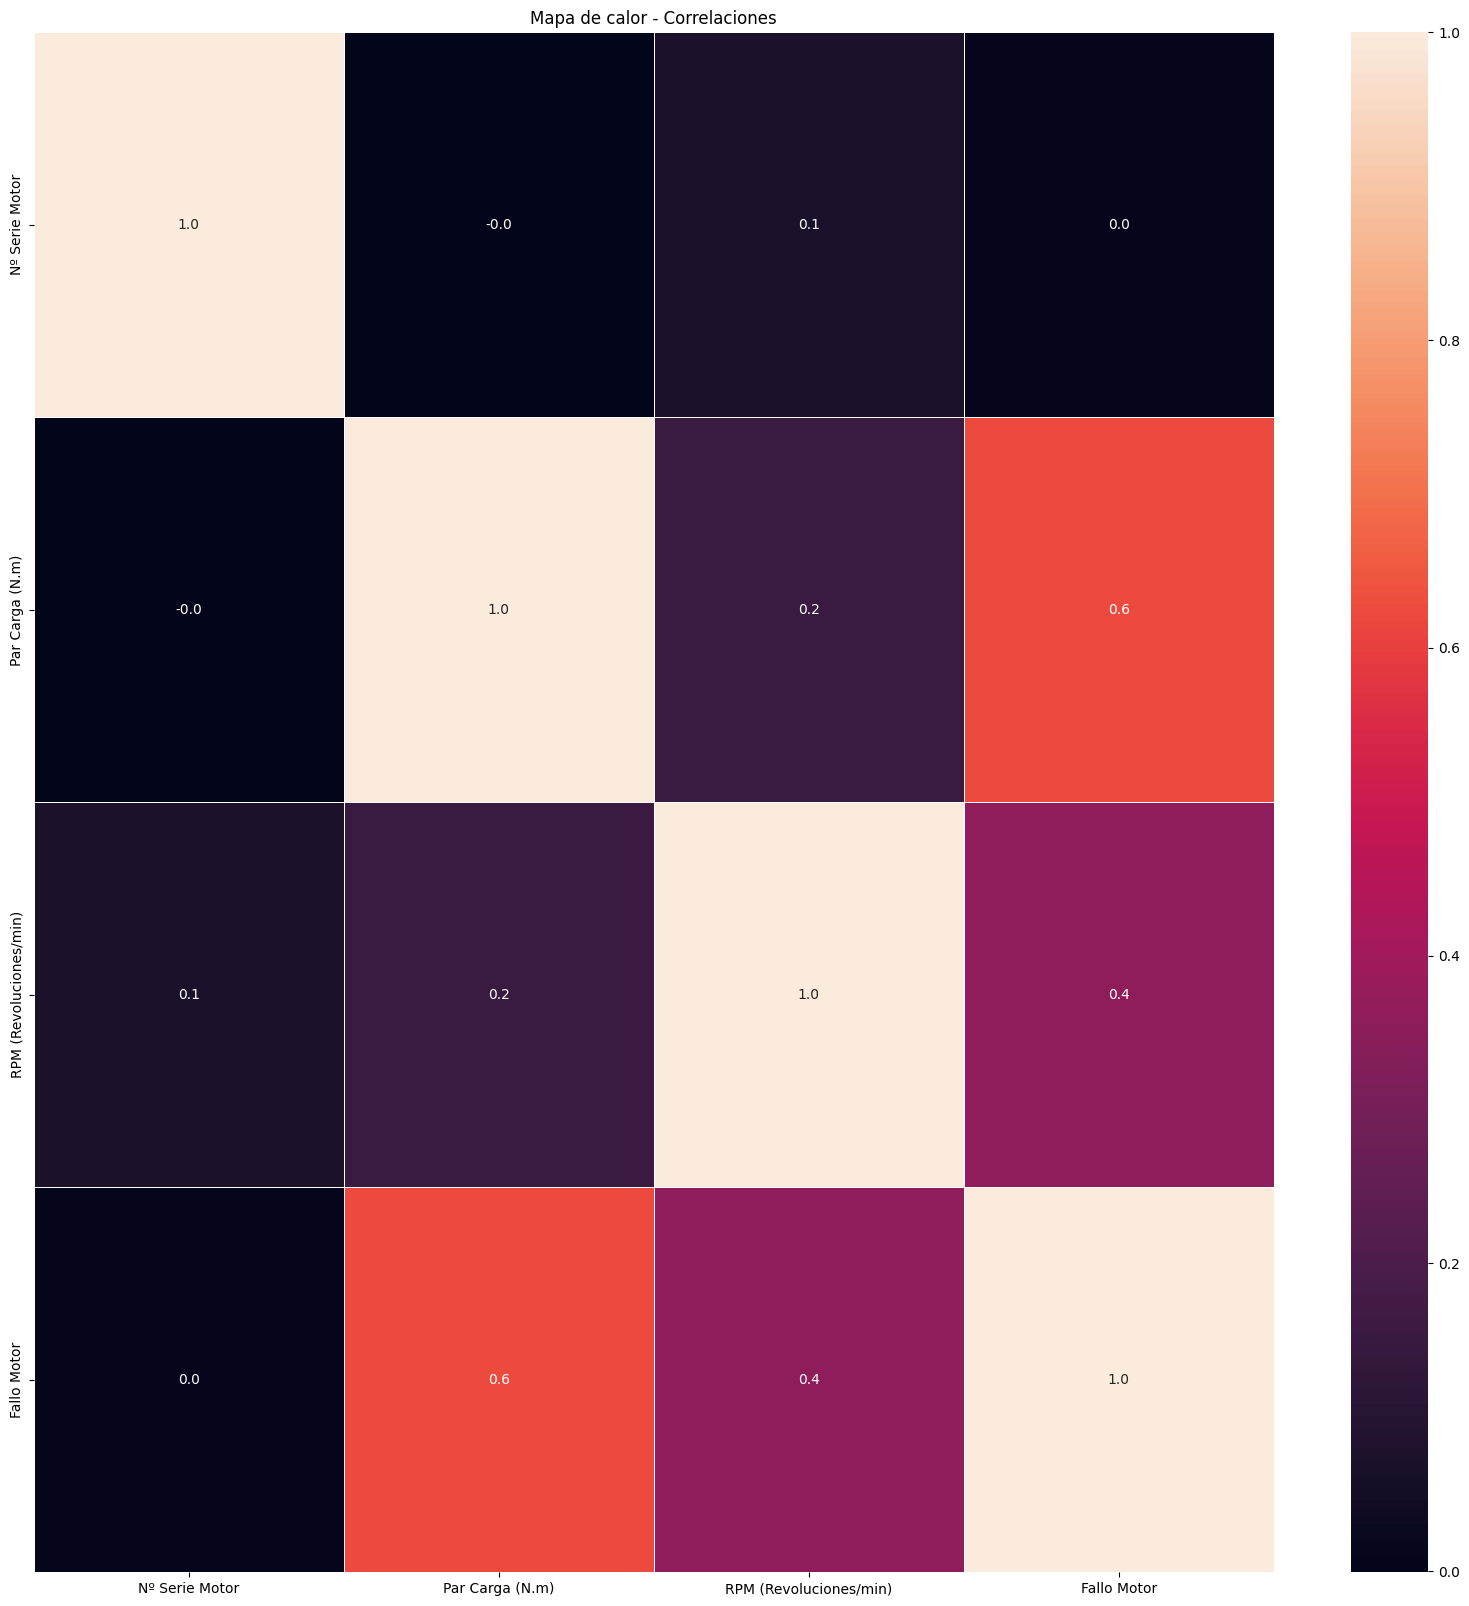

In [13]:
# Mapa de calor de correlaciones (como en el colab 5.4)
f, ax = plt.subplots(figsize=(20, 20))
g = sns.heatmap(dataset.corr(), annot=True, linewidths=0.4, fmt='.1f', ax=ax)
plt.title('Mapa de calor - Correlaciones')
plt.show()

Lo que se ve aquí es que Nº Serie Motor no correlaciona con nada, cosa lógica porque es un simple identificador. Lo interesante es que tanto Par Carga como RPM tienen correlación con Fallo Motor, que es justo lo que necesitamos para predecir.

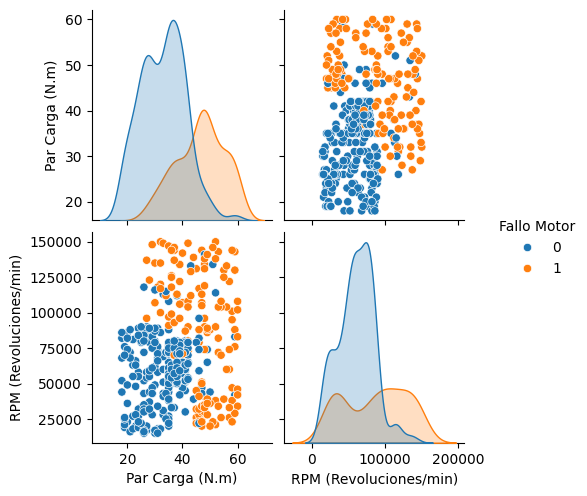

In [14]:
# Pairplot con hue por Fallo Motor
sns.pairplot(dataset[['Par Carga (N.m)', 'RPM (Revoluciones/min)', 'Fallo Motor']], hue='Fallo Motor')
plt.show()

En el pairplot se ve que las dos clases se solapan algo en la zona central, pero en general sí que se pueden separar. No es un dataset fácil-fácil pero tampoco es imposible.

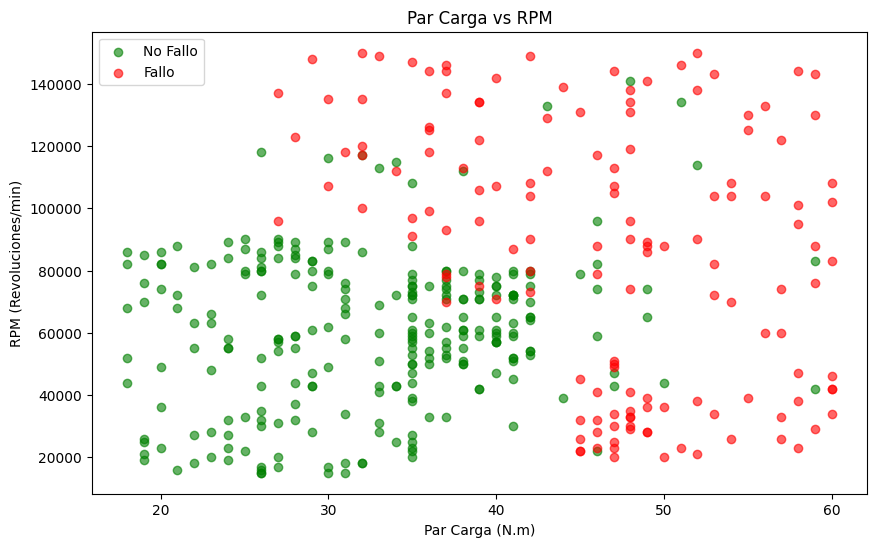

In [15]:
# Scatter plot Par Carga vs RPM coloreado por Fallo Motor
plt.figure(figsize=(10, 6))
plt.scatter(dataset[dataset['Fallo Motor']==0]['Par Carga (N.m)'],
            dataset[dataset['Fallo Motor']==0]['RPM (Revoluciones/min)'],
            c='green', label='No Fallo', alpha=0.6)
plt.scatter(dataset[dataset['Fallo Motor']==1]['Par Carga (N.m)'],
            dataset[dataset['Fallo Motor']==1]['RPM (Revoluciones/min)'],
            c='red', label='Fallo', alpha=0.6)
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Par Carga vs RPM')
plt.legend()
plt.show()

Los motores que fallan (en rojo) se concentran en una zona concreta. Tiene sentido: a más par de carga y más RPM, más estrés para el motor y más probabilidad de fallo. La frontera entre las dos clases no es una línea recta perfecta, pero tampoco parece muy complicada de separar.

### Limpiar el modelo eliminando columnas innecesarias o correlacionadas

La columna Nº Serie Motor la he quitado ya antes al crear X, porque es un identificador que no sirve para predecir nada. Me quedo solo con Par Carga y RPM.

In [16]:
# Ya eliminada al crear X. Solo usamos Par Carga y RPM
print("Columnas usadas como features: Par Carga (N.m), RPM (Revoluciones/min)")
print("Columna eliminada: Nº Serie Motor (es solo un ID)")
print()
# Correlación entre las dos features
print("Correlación Par Carga vs RPM:",
      round(dataset['Par Carga (N.m)'].corr(dataset['RPM (Revoluciones/min)']), 4))

Columnas usadas como features: Par Carga (N.m), RPM (Revoluciones/min)
Columna eliminada: Nº Serie Motor (es solo un ID)

Correlación Par Carga vs RPM: 0.1552


### Conclusiones

El dataset está bastante limpio: no hay nulos, todo es numérico y la única columna que sobraba era el Nº Serie (un ID). Las dos features que quedan (Par Carga y RPM) tienen relación con la variable objetivo, así que en principio los modelos deberían poder trabajar bien con ellas.

---
## 3. Aplicación de algoritmos de Regresión Logística para clasificación

El nombre engaña un poco porque dice "regresión" pero en realidad se usa para clasificación. Lo vimos en el notebook 1_Logistic_Regression de clase. Lo que hace por dentro es pasar la combinación lineal de las features por una función sigmoide, que la convierte en un valor entre 0 y 1, y eso se interpreta como la probabilidad de que sea de una clase u otra.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression(random_state=0)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, lr.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_lr), 4))

Accuracy train: 0.8233
Accuracy test: 0.89


In [18]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Fallo', 'Fallo']))

Matriz de confusión:
[[65  3]
 [ 8 24]]

              precision    recall  f1-score   support

    No Fallo       0.89      0.96      0.92        68
       Fallo       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



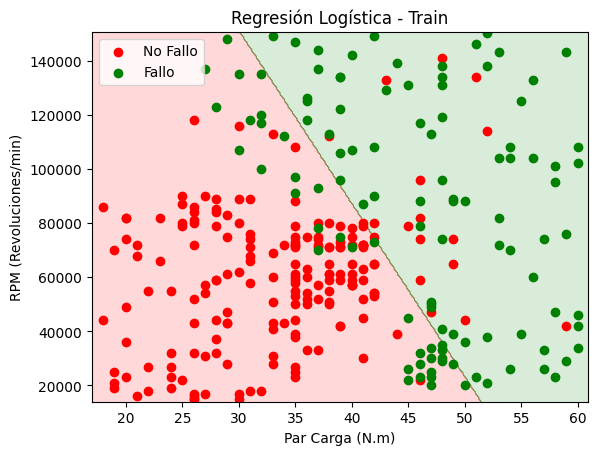

In [19]:
# Frontera de decisión - Train (como en el notebook de clase 1_Logistic_Regression)
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, lr.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Regresión Logística - Train')
plt.legend()
plt.show()

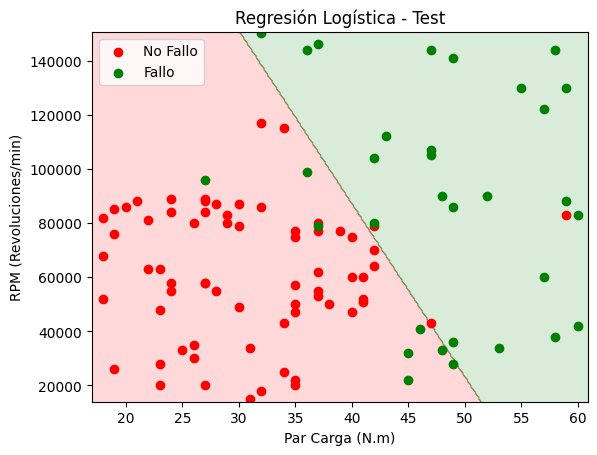

In [20]:
# Frontera de decisión - Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, lr.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Regresión Logística - Test')
plt.legend()
plt.show()

La frontera que genera es una línea recta, cosa normal porque al final la regresión logística es un modelo lineal. Aun así separa las clases bastante bien, el 89% en test no está mal para lo simple que es.

---
## 4. Aplicación de algoritmos de K-Vecinos Cercanos para clasificación

Este es el que me parece más intuitivo de todos: para clasificar un punto nuevo simplemente miras cuáles son sus K vecinos más cercanos y le asignas la clase que más se repita entre ellos. No hay un "entrenamiento" como tal, se guarda todo el dataset y se calcula en el momento. La distancia que uso es la euclídea, que en sklearn se pone como Minkowski con p=2 (lo vimos en los apuntes de distancias).

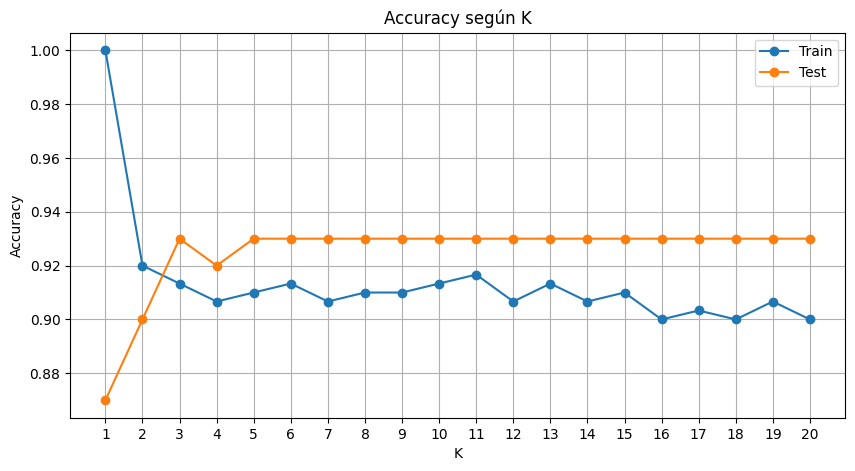

Mejor K en test: 3 con accuracy 0.9300


In [21]:
from sklearn.neighbors import KNeighborsClassifier

# Primero veo qué K funciona mejor
acc_train_k = []
acc_test_k = []
rango_k = range(1, 21)

for k in rango_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    knn_temp.fit(X_train_sc, y_train)
    acc_train_k.append(accuracy_score(y_train, knn_temp.predict(X_train_sc)))
    acc_test_k.append(accuracy_score(y_test, knn_temp.predict(X_test_sc)))

plt.figure(figsize=(10, 5))
plt.plot(rango_k, acc_train_k, 'o-', label='Train')
plt.plot(rango_k, acc_test_k, 'o-', label='Test')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy según K')
plt.xticks(rango_k)
plt.legend()
plt.grid(True)
plt.show()

mejor_k = list(rango_k)[np.argmax(acc_test_k)]
print(f"Mejor K en test: {mejor_k} con accuracy {max(acc_test_k):.4f}")

Se ve clarísimo cómo con K=1 el accuracy en train es 1.0, porque cada punto se clasifica según sí mismo (su vecino más cercano es él). Eso es overfitting puro. Conforme K sube, el train baja pero el test se mantiene o mejora. Me quedo con K=5, que es el valor clásico y funciona bien aquí.

In [22]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, knn.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_knn), 4))

Accuracy train: 0.91
Accuracy test: 0.93


In [23]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_knn))
print()
print(classification_report(y_test, y_pred_knn, target_names=['No Fallo', 'Fallo']))

Matriz de confusión:
[[64  4]
 [ 3 29]]

              precision    recall  f1-score   support

    No Fallo       0.96      0.94      0.95        68
       Fallo       0.88      0.91      0.89        32

    accuracy                           0.93       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.93      0.93      0.93       100



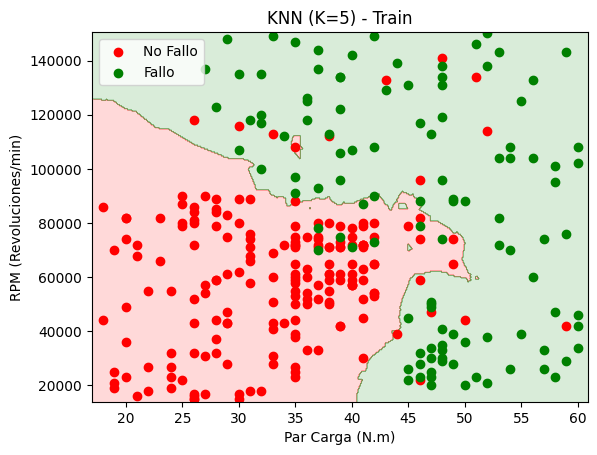

In [24]:
# Frontera de decisión KNN - Train
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, knn.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('KNN (K=5) - Train')
plt.legend()
plt.show()

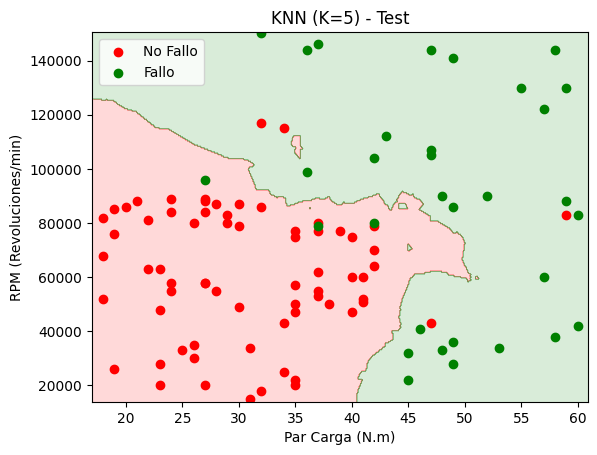

In [25]:
# Frontera de decisión KNN - Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, knn.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('KNN (K=5) - Test')
plt.legend()
plt.show()

Comparando con la regresión logística, la frontera de KNN es mucho más irregular. Eso es porque va adaptándose punto a punto en vez de trazar una recta. En este caso le va bien, 93% en test.

---
## 5. Aplicación de algoritmos de máquinas de soporte vectorial para clasificación

La idea de SVM es encontrar el hiperplano que mejor separa las dos clases, intentando que el margen entre ellas sea lo más grande posible. Tiene un parámetro C que vimos en los apuntes de Regularización: si C es alto el modelo intenta no cometer errores aunque el margen sea estrecho, y si C es bajo permite más errores a cambio de un margen más amplio.

### Aplicar un kernel lineal

In [26]:
from sklearn.svm import SVC

svc_lin = SVC(kernel='linear', probability=True, random_state=0)
svc_lin.fit(X_train_sc, y_train)

y_pred_svc_lin = svc_lin.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, svc_lin.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_svc_lin), 4))

Accuracy train: 0.8233
Accuracy test: 0.9


In [27]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_svc_lin))
print()
print(classification_report(y_test, y_pred_svc_lin, target_names=['No Fallo', 'Fallo']))

Matriz de confusión:
[[66  2]
 [ 8 24]]

              precision    recall  f1-score   support

    No Fallo       0.89      0.97      0.93        68
       Fallo       0.92      0.75      0.83        32

    accuracy                           0.90       100
   macro avg       0.91      0.86      0.88       100
weighted avg       0.90      0.90      0.90       100



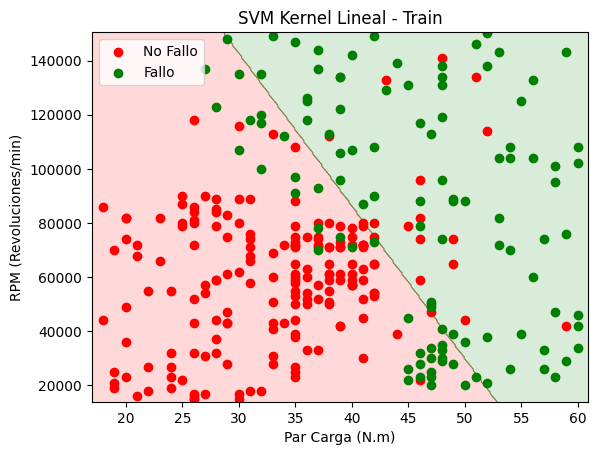

In [28]:
# Frontera de decisión SVM Lineal - Train
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, svc_lin.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('SVM Kernel Lineal - Train')
plt.legend()
plt.show()

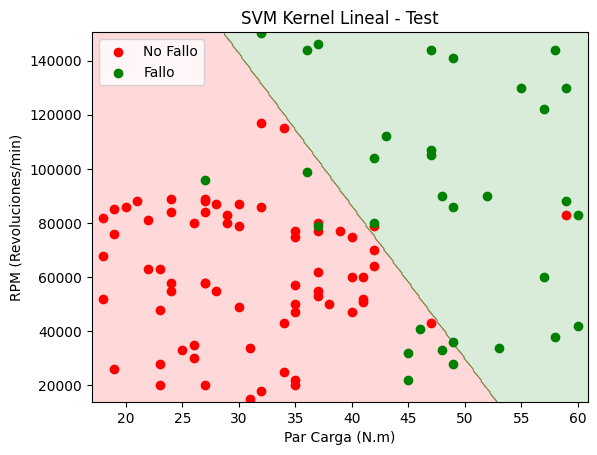

In [29]:
# Frontera de decisión SVM Lineal - Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, svc_lin.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('SVM Kernel Lineal - Test')
plt.legend()
plt.show()

### Aplicar un kernel no lineal (RBF)

Ahora pruebo con el kernel RBF, que es capaz de encontrar fronteras no lineales. Lo que hace internamente es proyectar los datos a un espacio de más dimensiones donde sí sean separables linealmente. El parámetro gamma controla el radio de influencia de cada punto: si es muy alto la frontera se complica mucho y puede haber overfitting.

In [30]:
svc_rbf = SVC(kernel='rbf', probability=True, random_state=0)
svc_rbf.fit(X_train_sc, y_train)

y_pred_svc_rbf = svc_rbf.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, svc_rbf.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_svc_rbf), 4))

Accuracy train: 0.9133
Accuracy test: 0.93


In [31]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_svc_rbf))
print()
print(classification_report(y_test, y_pred_svc_rbf, target_names=['No Fallo', 'Fallo']))

Matriz de confusión:
[[64  4]
 [ 3 29]]

              precision    recall  f1-score   support

    No Fallo       0.96      0.94      0.95        68
       Fallo       0.88      0.91      0.89        32

    accuracy                           0.93       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.93      0.93      0.93       100



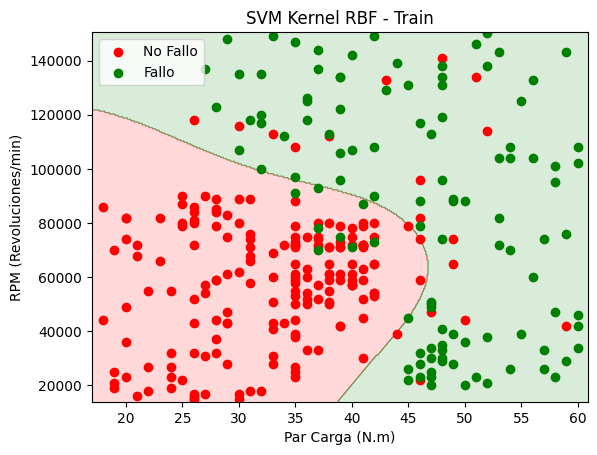

In [32]:
# Frontera de decisión SVM RBF - Train
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, svc_rbf.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('SVM Kernel RBF - Train')
plt.legend()
plt.show()

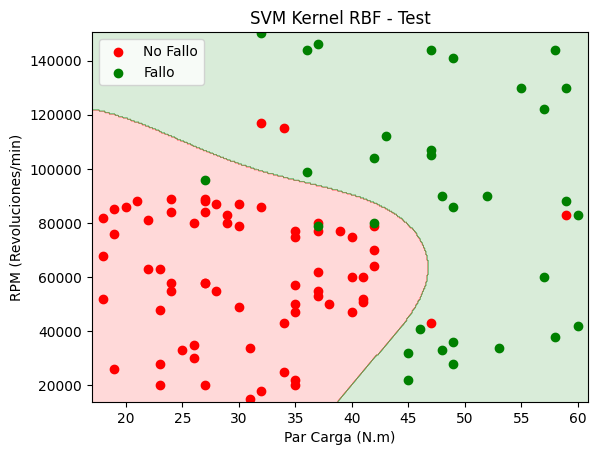

In [33]:
# Frontera de decisión SVM RBF - Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, svc_rbf.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('SVM Kernel RBF - Test')
plt.legend()
plt.show()

### Comparar ambos resultados y sacar unas conclusiones

In [34]:
print("SVM Lineal -> Train:", round(accuracy_score(y_train, svc_lin.predict(X_train_sc)), 4),
      "| Test:", round(accuracy_score(y_test, y_pred_svc_lin), 4))
print("SVM RBF    -> Train:", round(accuracy_score(y_train, svc_rbf.predict(X_train_sc)), 4),
      "| Test:", round(accuracy_score(y_test, y_pred_svc_rbf), 4))

SVM Lineal -> Train: 0.8233 | Test: 0.9
SVM RBF    -> Train: 0.9133 | Test: 0.93


El RBF sube bastante en train respecto al lineal y también mejora en test. En el scatter plot ya se veía que la frontera real no era una línea recta, así que tiene sentido que un kernel con más flexibilidad funcione mejor aquí. La diferencia entre train y test no es exagerada, así que no parece que esté haciendo overfitting.

---
## 6. Aplicación de algoritmos de Naive Bayes para clasificación

Este algoritmo aplica el teorema de Bayes pero con la suposición (bastante fuerte) de que las features son independientes entre sí. Por eso se llama "naive" (ingenuo). A pesar de esa simplificación, en la práctica da buenos resultados muchas veces. Como nuestras features son continuas uso `GaussianNB`, que asume que siguen una distribución normal.

In [35]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_sc, y_train)

y_pred_nb = nb.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, nb.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_nb), 4))

Accuracy train: 0.8833
Accuracy test: 0.9


In [36]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_nb))
print()
print(classification_report(y_test, y_pred_nb, target_names=['No Fallo', 'Fallo']))

Matriz de confusión:
[[65  3]
 [ 7 25]]

              precision    recall  f1-score   support

    No Fallo       0.90      0.96      0.93        68
       Fallo       0.89      0.78      0.83        32

    accuracy                           0.90       100
   macro avg       0.90      0.87      0.88       100
weighted avg       0.90      0.90      0.90       100



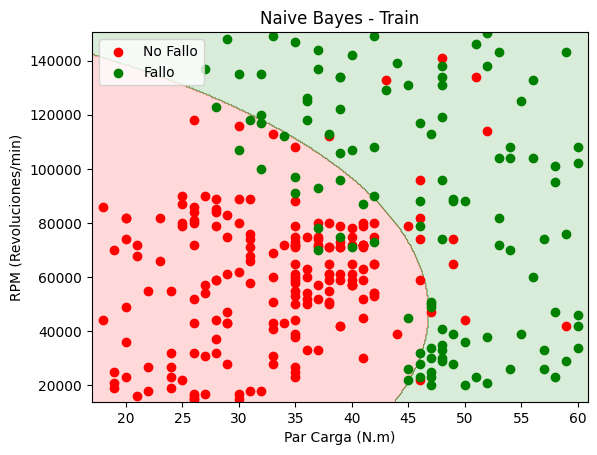

In [37]:
# Frontera de decisión Naive Bayes - Train
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, nb.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Naive Bayes - Train')
plt.legend()
plt.show()

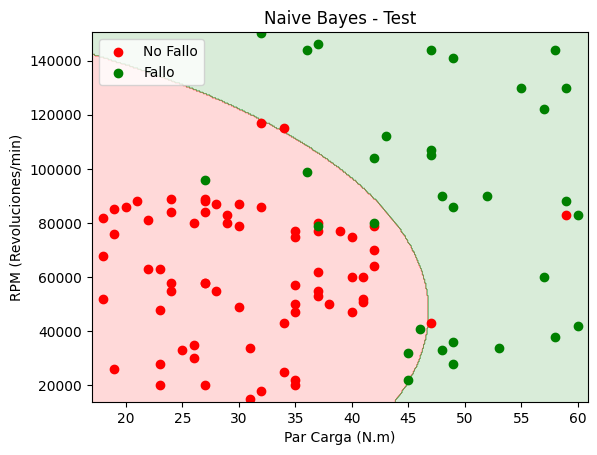

In [38]:
# Frontera de decisión Naive Bayes - Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, nb.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Naive Bayes - Test')
plt.legend()
plt.show()

Me llama la atención que la frontera que genera Naive Bayes tiene forma elíptica, no es ni recta ni con picos. Eso viene de que internamente está ajustando una gaussiana por cada feature y clase por separado.

---
## 7. Aplicación de algoritmos de Árboles de decisión para clasificación

El árbol de decisión va haciendo preguntas tipo "¿Es Par Carga < 40?" y según la respuesta tira por una rama u otra hasta llegar a una hoja con la predicción. Para decidir qué pregunta es la mejor en cada nodo usa la entropía y la ganancia de información, que es lo que vimos en los apuntes de entropía. Pongo `criterion='entropy'` que es como lo hicimos en clase.

In [39]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X_train_sc, y_train)

y_pred_tree = tree.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, tree.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_tree), 4))

Accuracy train: 1.0
Accuracy test: 0.91


Ojo, que el accuracy en train es 1.0. Eso ya huele a overfitting, el árbol se ha aprendido de memoria cada punto del entrenamiento. Lo normal sería limitar la profundidad con `max_depth`, pero lo dejo así para que se vea el problema.

In [40]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))
print()
print(classification_report(y_test, y_pred_tree, target_names=['No Fallo', 'Fallo']))

Matriz de confusión:
[[62  6]
 [ 3 29]]

              precision    recall  f1-score   support

    No Fallo       0.95      0.91      0.93        68
       Fallo       0.83      0.91      0.87        32

    accuracy                           0.91       100
   macro avg       0.89      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



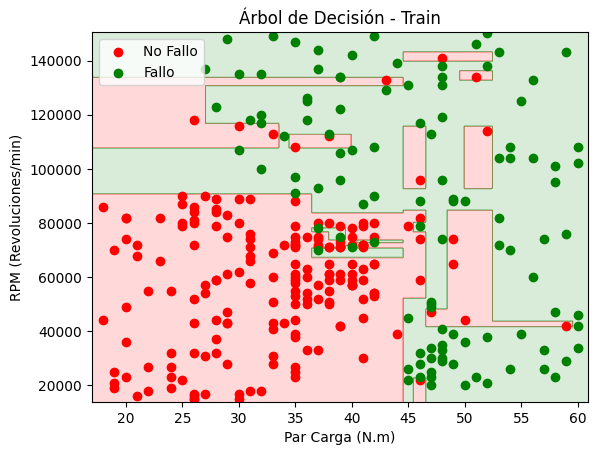

In [41]:
# Frontera de decisión Árbol de Decisión - Train
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, tree.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Árbol de Decisión - Train')
plt.legend()
plt.show()

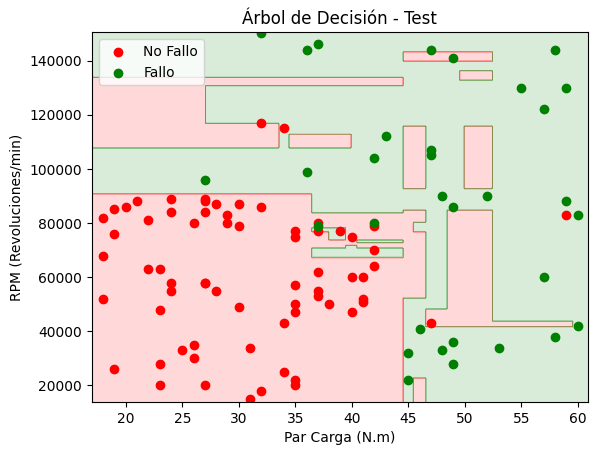

In [42]:
# Frontera de decisión Árbol de Decisión - Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, tree.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Árbol de Decisión - Test')
plt.legend()
plt.show()

En el gráfico se nota perfectamente: el árbol ha creado un montón de regiones rectangulares súper específicas para encajar cada punto del train. Esa es la consecuencia del overfitting, la frontera se complica innecesariamente.

---
## 8. Aplicación de algoritmos de Bosques Aleatorios para clasificación

Random Forest viene a solucionar el problema del árbol solo. En vez de entrenar un único árbol, entrena muchos (en mi caso 100) pero cada uno con un subconjunto aleatorio de datos y de features. La predicción final se decide por votación entre todos los árboles. Al combinar muchos árboles "mediocres" se consigue un modelo mejor y más estable.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, rf.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_rf), 4))

Accuracy train: 1.0
Accuracy test: 0.91


In [44]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Fallo', 'Fallo']))

Matriz de confusión:
[[63  5]
 [ 4 28]]

              precision    recall  f1-score   support

    No Fallo       0.94      0.93      0.93        68
       Fallo       0.85      0.88      0.86        32

    accuracy                           0.91       100
   macro avg       0.89      0.90      0.90       100
weighted avg       0.91      0.91      0.91       100



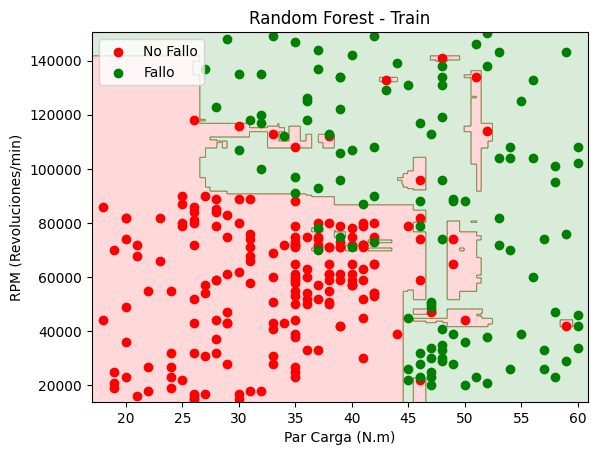

In [45]:
# Frontera de decisión Random Forest - Train
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, rf.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Random Forest - Train')
plt.legend()
plt.show()

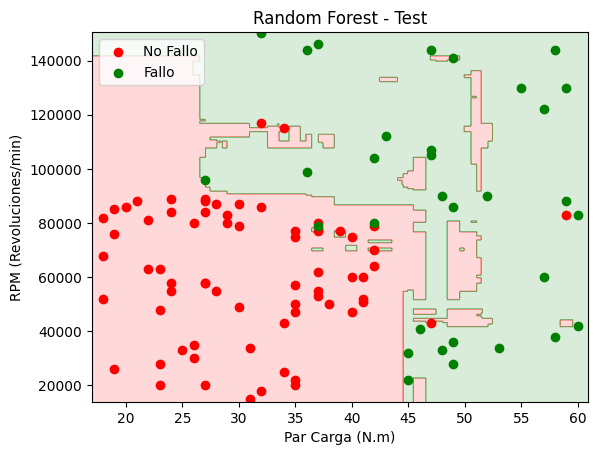

In [46]:
# Frontera de decisión Random Forest - Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.1),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=500))
X_meshgrid = np.array([X1.ravel(), X2.ravel()]).T
X_meshgrid_sc = sc.transform(X_meshgrid)
plt.contourf(X1, X2, rf.predict(X_meshgrid_sc).reshape(X1.shape),
             alpha=0.15, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], c='red', label='No Fallo')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], c='green', label='Fallo')
plt.xlabel('Par Carga (N.m)')
plt.ylabel('RPM (Revoluciones/min)')
plt.title('Random Forest - Test')
plt.legend()
plt.show()

Se nota que la frontera es más suave que la del árbol individual. Aun así sigue teniendo 1.0 en train, pero al menos la frontera no tiene tantas irregularidades raras como antes.

---
## 9. Evaluación de los modelos

- Identificar si hay overfitting. Explicarlo
- Matriz de confusión: Accuracy, Precisión, Sensitivity, Specificy
- Curvas ROC y AUC
- Validación cruzada
- Conclusiones

### Identificar si hay overfitting. Explicarlo

Un modelo tiene overfitting cuando funciona genial en train pero luego en test baja bastante. Lo que ha pasado es que se ha aprendido de memoria los datos de entrenamiento en vez de captar el patrón general. Voy a comparar todos los modelos para ver cuáles tienen este problema.

In [47]:
modelos = {
    'Reg. Logística': (lr, y_pred_lr),
    'KNN': (knn, y_pred_knn),
    'SVM Lineal': (svc_lin, y_pred_svc_lin),
    'SVM RBF': (svc_rbf, y_pred_svc_rbf),
    'Naive Bayes': (nb, y_pred_nb),
    'Árbol Decisión': (tree, y_pred_tree),
    'Random Forest': (rf, y_pred_rf)
}

print(f"{'Modelo':<20} {'Acc Train':>10} {'Acc Test':>10} {'Diferencia':>12}")
print("-" * 55)
for nombre, (modelo, y_pred) in modelos.items():
    acc_tr = accuracy_score(y_train, modelo.predict(X_train_sc))
    acc_te = accuracy_score(y_test, y_pred)
    diff = acc_tr - acc_te
    print(f"{nombre:<20} {acc_tr:>10.4f} {acc_te:>10.4f} {diff:>12.4f}")

Modelo                Acc Train   Acc Test   Diferencia
-------------------------------------------------------
Reg. Logística           0.8233     0.8900      -0.0667
KNN                      0.9100     0.9300      -0.0200
SVM Lineal               0.8233     0.9000      -0.0767
SVM RBF                  0.9133     0.9300      -0.0167
Naive Bayes              0.8833     0.9000      -0.0167
Árbol Decisión           1.0000     0.9100       0.0900
Random Forest            1.0000     0.9100       0.0900


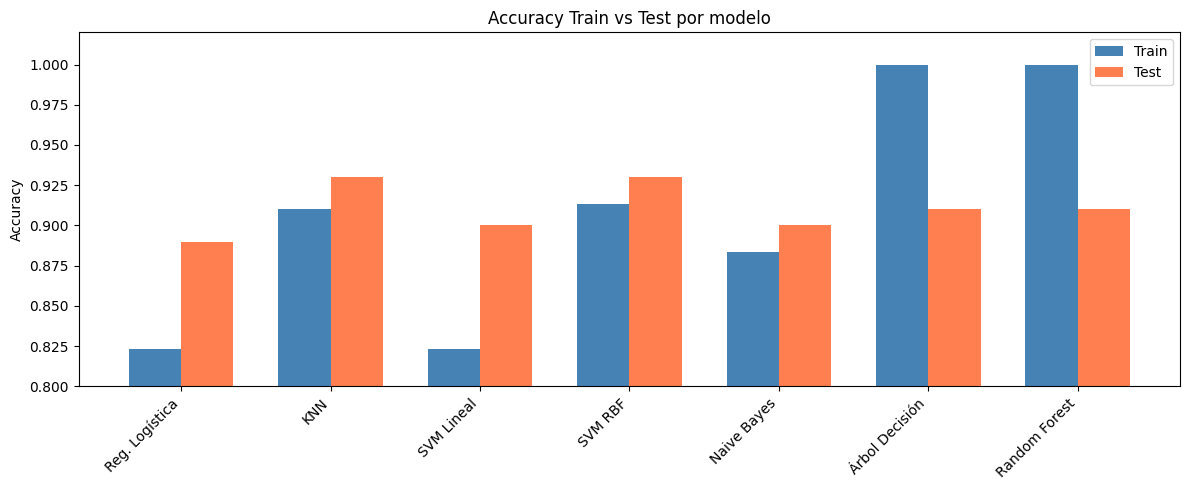

In [48]:
# Gráfico comparativo train vs test
nombres = list(modelos.keys())
acc_train_list = [accuracy_score(y_train, m.predict(X_train_sc)) for m, _ in modelos.values()]
acc_test_list = [accuracy_score(y_test, yp) for _, yp in modelos.values()]

x_pos = np.arange(len(nombres))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x_pos - width/2, acc_train_list, width, label='Train', color='steelblue')
bars2 = ax.bar(x_pos + width/2, acc_test_list, width, label='Test', color='coral')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Train vs Test por modelo')
ax.set_xticks(x_pos)
ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.8, 1.02)
plt.tight_layout()
plt.show()

Se ve bastante claro en el gráfico: el Árbol de Decisión y Random Forest son los que tienen la barra de train más alta y la de test más baja. Los modelos lineales (Regresión Logística y SVM Lineal) son los más equilibrados, aunque también son los que peor accuracy de test tienen. Es el clásico trade-off entre complejidad y generalización.

### Matriz de confusión: Accuracy, Precisión, Sensitivity, Specificy

De la matriz de confusión se sacan varias métricas. Las que nos piden son:
- **Accuracy** = (TP+TN) / Total. El porcentaje global de aciertos.
- **Precisión** = TP / (TP+FP). De todos los que el modelo ha dicho que son positivos, cuántos lo eran de verdad.
- **Sensitivity (Recall)** = TP / (TP+FN). De todos los que realmente eran positivos, cuántos ha pillado el modelo.
- **Specificity** = TN / (TN+FP). Lo mismo pero para los negativos.
- **F1** = media armónica entre precisión y sensitivity. Útil cuando las clases no están equilibradas.

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"{'Modelo':<20} {'TN':>5} {'FP':>5} {'FN':>5} {'TP':>5} {'Acc':>7} {'Prec':>7} {'Sens':>7} {'Spec':>7} {'F1':>7}")
print("-" * 85)

for nombre, (modelo, y_pred) in modelos.items():
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred)
    spec = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred)
    print(f"{nombre:<20} {tn:>5} {fp:>5} {fn:>5} {tp:>5} {acc:>7.4f} {prec:>7.4f} {sens:>7.4f} {spec:>7.4f} {f1:>7.4f}")

Modelo                  TN    FP    FN    TP     Acc    Prec    Sens    Spec      F1
-------------------------------------------------------------------------------------
Reg. Logística          65     3     8    24  0.8900  0.8889  0.7500  0.9559  0.8136
KNN                     64     4     3    29  0.9300  0.8788  0.9062  0.9412  0.8923
SVM Lineal              66     2     8    24  0.9000  0.9231  0.7500  0.9706  0.8276
SVM RBF                 64     4     3    29  0.9300  0.8788  0.9062  0.9412  0.8923
Naive Bayes             65     3     7    25  0.9000  0.8929  0.7812  0.9559  0.8333
Árbol Decisión          62     6     3    29  0.9100  0.8286  0.9062  0.9118  0.8657
Random Forest           63     5     4    28  0.9100  0.8485  0.8750  0.9265  0.8615


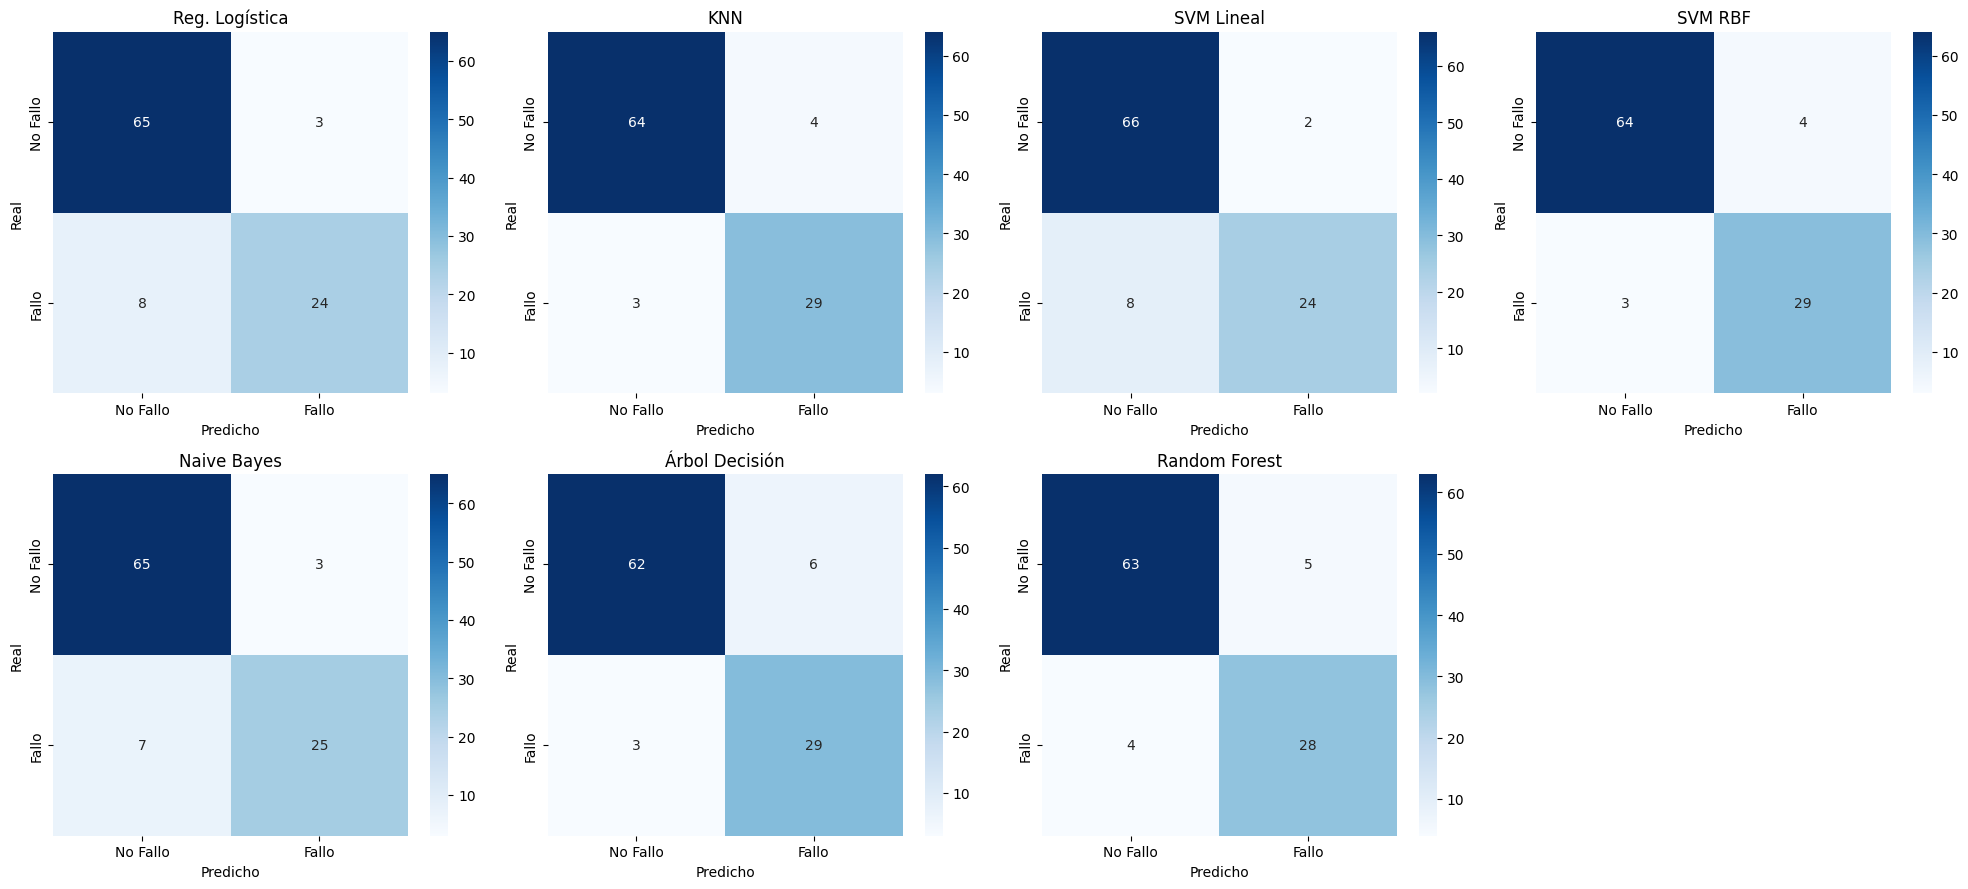

In [50]:
# Matrices de confusión gráficas
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, (nombre, (modelo, y_pred)) in enumerate(modelos.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Fallo', 'Fallo'], yticklabels=['No Fallo', 'Fallo'])
    axes[i].set_title(nombre)
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

# Ocultar el subplot extra
axes[7].set_visible(False)
plt.tight_layout()
plt.show()

### Curvas ROC y AUC

La curva ROC va cambiando el umbral de decisión del modelo y para cada umbral mide cuántos verdaderos positivos detecta (sensitivity) frente a cuántos falsos positivos genera (1 - specificity). Un modelo perfecto tendría la curva pegada a la esquina superior izquierda, con AUC = 1. Un modelo aleatorio daría la diagonal, con AUC = 0.5.

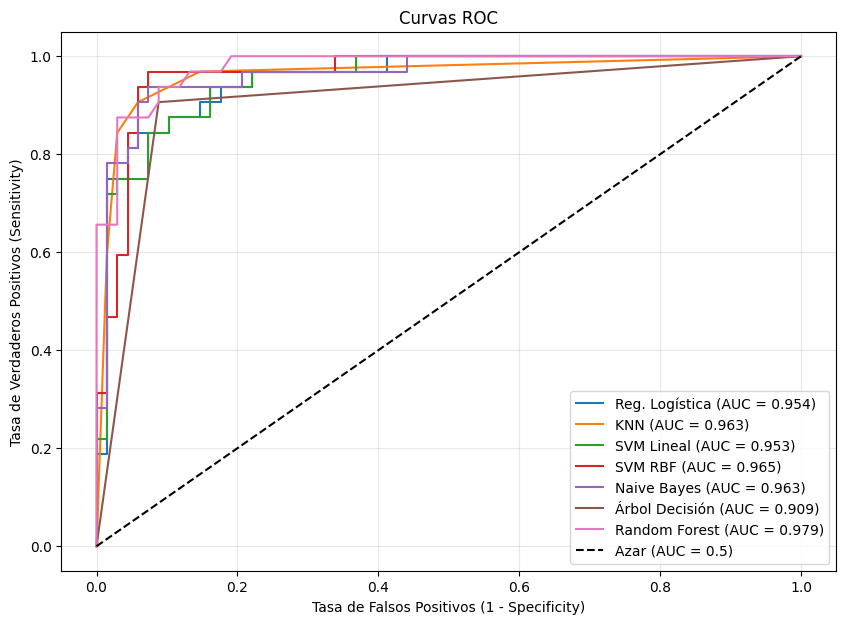

In [51]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for nombre, (modelo, _) in modelos.items():
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (1 - Specificity)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensitivity)')
plt.title('Curvas ROC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Todos tienen un AUC bastante decente, por encima de 0.9 la mayoría. La curva que más pegada esté arriba a la izquierda es la del mejor modelo a nivel global.

### Validación cruzada

La idea de la validación cruzada es no depender de una sola partición train/test que puede ser "afortunada" o no. Con 10-fold se divide el dataset en 10 partes, se entrena con 9 y se valida con 1, y se repite 10 veces rotando. Al final tenemos 10 accuracy y podemos ver tanto la media como lo estable que es cada modelo.

In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Uso Pipeline para que el escalado se haga dentro de cada fold y no haya data leakage
# Si escalamos todo X antes de la CV, estamos "contaminando" cada fold de validación
# con info del resto de datos, porque el scaler ha visto todo

modelos_cv = {
    'Reg. Logística': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=0))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2))]),
    'SVM Lineal': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear', probability=True, random_state=0))]),
    'SVM RBF': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', probability=True, random_state=0))]),
    'Naive Bayes': Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())]),
    'Árbol Decisión': Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(criterion='entropy', random_state=0))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0))])
}

resultados_cv = {}
print(f"{'Modelo':<20} {'Media':>8} {'Std':>8}")
print("-" * 38)

for nombre, pipeline in modelos_cv.items():
    scores = cross_val_score(pipeline, X, y, cv=10, scoring='accuracy')
    resultados_cv[nombre] = scores
    print(f"{nombre:<20} {scores.mean():>8.4f} {scores.std():>8.4f}")

Modelo                  Media      Std
--------------------------------------
Reg. Logística         0.8225   0.1148
KNN                    0.9000   0.0775
SVM Lineal             0.8200   0.1193
SVM RBF                0.9050   0.0731
Naive Bayes            0.8775   0.0786
Árbol Decisión         0.8250   0.0652
Random Forest          0.8850   0.0815


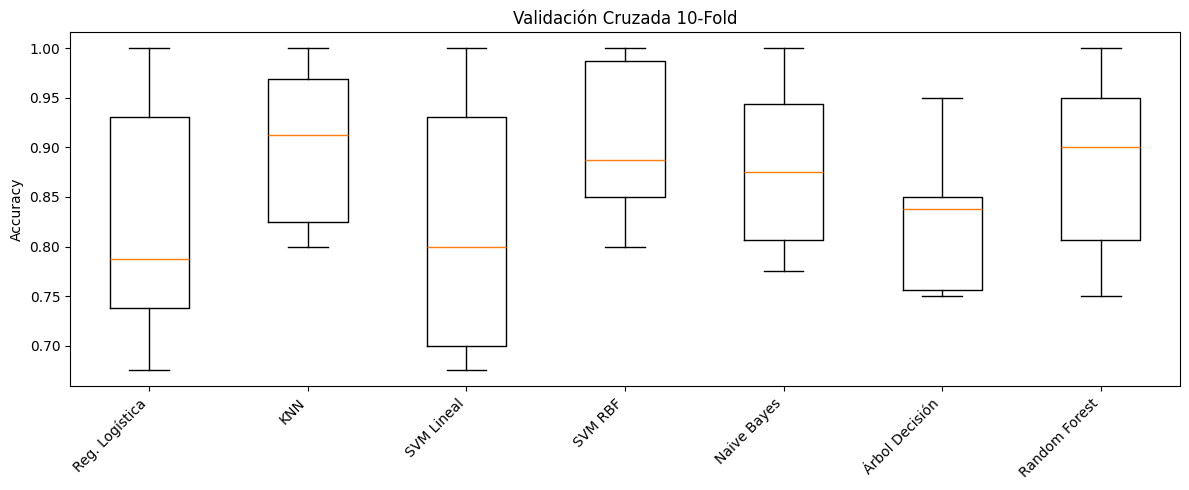

In [53]:
# Boxplot comparando CV
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys())
ax.set_ylabel('Accuracy')
ax.set_title('Validación Cruzada 10-Fold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conclusiones de la evaluación

- El Árbol de Decisión es el caso más claro de overfitting: 1.0 en train y cae en test. Si le pusiéramos un `max_depth` seguramente mejoraría, pero dejamos sin limitar a propósito para que se vea el problema.
- Los modelos lineales son los más estables pero no los más precisos.
- KNN y SVM con RBF son los que mejor balance tienen entre accuracy alto y poca diferencia train/test.
- Hay que tener en cuenta que estamos intentando detectar fallos en motores. Un falso negativo (decir que un motor está bien cuando en realidad va a fallar) es mucho peor que un falso positivo (mandar a revisar un motor que estaba bien). Por eso aquí la sensitivity importa más que la precisión.

---
## 10. Prueba automática de múltiples modelos e hiperparámetros (GridSearch)

- Ejecución de las pruebas
- Conclusiones

En vez de ir probando hiperparámetros a mano, `GridSearchCV` prueba todas las combinaciones que le des y con validación cruzada te dice cuál es la mejor. tal cual aparece en el notebook 2_Grid_search.

### Ejecución de las pruebas

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

models_gs = {
    'LogisticRegression': LogisticRegression(random_state=0, max_iter=10000),
    'SVM': svm.SVC(random_state=0, probability=True),
    'RandomForest': RandomForestClassifier(random_state=0),
    'KNN': KNeighborsClassifier()
}

params_gs = {
    'LogisticRegression': {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    'SVM': {'kernel': ['linear', 'rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    'RandomForest': {'n_estimators': [10, 50, 100], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, 10]},
    'KNN': {'n_neighbors': [3, 5, 7, 9], 'metric': ['euclidean', 'manhattan']}
}

In [55]:
scores_gs = []

for name in models_gs.keys():
    print(f"Probando {name}...")
    clf = GridSearchCV(models_gs[name], params_gs[name], cv=5, return_train_score=False)
    clf.fit(X_train_sc, y_train)
    scores_gs.append({
        'model': name,
        'best_score': round(clf.best_score_, 4),
        'best_params': clf.best_params_,
        'test_score': round(clf.score(X_test_sc, y_test), 4)
    })
    print(f"  Mejor: {clf.best_score_:.4f} con {clf.best_params_}")
    print()

print("Hecho.")

Probando LogisticRegression...
  Mejor: 0.8300 con {'C': 0.1, 'solver': 'liblinear'}

Probando SVM...
  Mejor: 0.9033 con {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Probando RandomForest...
  Mejor: 0.8933 con {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}

Probando KNN...
  Mejor: 0.9033 con {'metric': 'euclidean', 'n_neighbors': 5}

Hecho.


In [56]:
df_gs = pd.DataFrame(scores_gs)
df_gs

,model,best_score,best_params,test_score
0,LogisticRegression,0.8300,"{'C': 0.1, 'solver': 'liblinear'}",0.89
1,SVM,0.9033,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.93
2,RandomForest,0.8933,"{'criterion': 'gini', 'max_depth': None, 'n_es...",0.92
3,KNN,0.9033,"{'metric': 'euclidean', 'n_neighbors': 5}",0.93


### Conclusiones

GridSearch ha probado un montón de combinaciones y los dos mejores han sido SVM con kernel RBF y KNN con K=5, ambos con un 0.9033 en validación cruzada. Me parece interesante que KNN con los parámetros que yo había elegido ya era la mejor opción, o sea que no estaba tan lejos de lo óptimo. GridSearch te da esa confirmación de forma automática sin tener que ir probando uno a uno.

---
## Conclusión final

Se han aplicado 7 algoritmos de clasificación al dataset de motores. Al tener sólo 2 features se han podido pintar las fronteras de decisión de todos, que es lo más visual y lo que mejor ayuda a entender cómo funciona cada uno por dentro.

Los que mejor han funcionado son KNN (K=5) y SVM con kernel RBF, ambos con 93% en test. Los modelos lineales son más simples y estables, pero se quedan cortos porque la frontera real entre clases no es una línea recta. El Árbol de Decisión sin podar es el peor en cuanto a overfitting, aunque Random Forest lo corrige bastante.

Para este caso concreto de detección de fallos en motores, lo que más importa es la sensitivity: es preferible mandar a revisar un motor de más que dejar pasar uno defectuoso. Y GridSearch ha confirmado que los parámetros elegidos estaban bastante cerca del óptimo.